In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import os
import argparse
from src.algorithms.couta_algo import COUTA

In [2]:
# parser = argparse.ArgumentParser()
# parser.add_argument('--type', type=str, default=f'point')
# args = parser.parse_args()

res_dir = '@results_showcase/'
os.makedirs(res_dir, exist_ok=True)

df = pd.read_csv('data_processed/4_1.csv')
df = df.iloc[:, [5, 6]].head(7000)

# df = pd.read_csv('data_processed/4_3.csv')
# df = df.iloc[:, [5, 6]].head(7000)

# df = pd.read_csv('data_processed/3_10.csv')
# df = df.iloc[:, [5, 6]].head(7000)


# For normal data validation. Maximum score is 394.9. So we set the threshold to 800.
# df = pd.read_csv('data_processed/blue_range_bmereading_3.csv')
# df = df.iloc[:, [5, 6]].head(40000)

# point-wise anomalies
path = 'saved_models/bushfire_detection_point.pth'

model_configs = {'load_model_path': path}

model = COUTA(**model_configs)

point_scores = model.predict(df)['score_t']

print(point_scores.max())
np.save(res_dir + f'showcase_point_score_couta.npy', point_scores)


# pattern-wise anomalies
path = 'saved_models/bushfire_detection_pattern.pth'

model_configs = {'load_model_path': path}

model = COUTA(**model_configs)

pattern_scores = model.predict(df)['score_t']

df['pattern_scores'] = pattern_scores

print(pattern_scores.max())
np.save(res_dir + f'showcase_pattern_score_couta.npy', pattern_scores)

{'sequence_length': 100, 'stride': 1, 'num_epochs': 40, 'batch_size': 64, 'lr': 0.0001, 'ss_type': 'FULL', 'hidden_dims': 16, 'emb_dim': 16, 'rep_hidden': 16, 'pretext_hidden': 16, 'kernel_size': 2, 'dropout': 0.0, 'bias': True, 'alpha': 0.1, 'neg_batch_ratio': 0.2, 'es': False, 'train_val_pc': 0.25, 'seed': 0, 'model_dir': 'couta_model/', 'save_model_path': None, 'load_model_path': 'saved_models/bushfire_detection_point.pth', 'nac': True, 'umc': True}
15164.875
{'sequence_length': 100, 'stride': 1, 'num_epochs': 40, 'batch_size': 64, 'lr': 0.0001, 'ss_type': 'FULL', 'hidden_dims': 16, 'emb_dim': 16, 'rep_hidden': 16, 'pretext_hidden': 16, 'kernel_size': 2, 'dropout': 0.0, 'bias': True, 'alpha': 0.1, 'neg_batch_ratio': 0.2, 'es': False, 'train_val_pc': 0.25, 'seed': 0, 'model_dir': 'couta_model/', 'save_model_path': None, 'load_model_path': 'saved_models/bushfire_detection_pattern.pth', 'nac': True, 'umc': True}
1897.871826171875


In [3]:
df

,eCO2,TVOC,pattern_scores
0,400,0,0.000000
1,400,0,0.000000
2,400,0,0.000000
3,400,0,0.000000
4,400,0,0.000000
...,...,...,...
6995,456,82,5.773591
6996,462,76,6.923434
6997,463,75,7.000023
6998,462,78,7.393051


In [4]:
data_lst = []
y_lst = []
for type in ['point', 'pattern']:
    
    # df = pd.read_csv(f'data_processed/synthetic_{type}.csv', index_col=0)
    df['label01'] = point_scores>800

    label01 = df['label01']
    indices = [index for index, value in enumerate(label01) if value == 1]
    print(indices)
    
    df = df.drop(['label01'], axis=1)

    y = label01
    data = df.values[:, 0]

    if type == 'pattern':
        anom_pairs = []
        if y is not None:
            anom_index = np.where(y == 1)[0]
            tmp_seg = []
            for i in anom_index:
                tmp_seg.append(i)
                if i + 1 not in anom_index:
                    anom_pairs.append((tmp_seg[0], tmp_seg[-1]))
                    tmp_seg = []
    
    data_lst.append(data)
    y_lst.append(y)

[252, 253, 254, 2146, 2147, 2148, 2149, 2150, 2151, 2208, 2209, 2210, 2214, 2215, 2216, 2217, 2218, 2219, 2220, 2221, 2222, 2223, 2224, 2225, 2233, 2234, 2235, 4068, 4069, 4070, 4071, 4072, 4073, 4074, 4075, 4076, 4077, 4078, 4083, 4084, 4085, 4086, 4087, 4088, 4089, 4090, 4164, 4165, 4166, 4167, 4281, 4282, 4283, 4284, 4285, 4286, 6598, 6599, 6600, 6698, 6699, 6700, 6701, 6702, 6703, 6704, 6705, 6706, 6707, 6708, 6709, 6710, 6711, 6712, 6713, 6714, 6715, 6716, 6717, 6718, 6719, 6720]
[252, 253, 254, 2146, 2147, 2148, 2149, 2150, 2151, 2208, 2209, 2210, 2214, 2215, 2216, 2217, 2218, 2219, 2220, 2221, 2222, 2223, 2224, 2225, 2233, 2234, 2235, 4068, 4069, 4070, 4071, 4072, 4073, 4074, 4075, 4076, 4077, 4078, 4083, 4084, 4085, 4086, 4087, 4088, 4089, 4090, 4164, 4165, 4166, 4167, 4281, 4282, 4283, 4284, 4285, 4286, 6598, 6599, 6600, 6698, 6699, 6700, 6701, 6702, 6703, 6704, 6705, 6706, 6707, 6708, 6709, 6710, 6711, 6712, 6713, 6714, 6715, 6716, 6717, 6718, 6719, 6720]


In [5]:
path = '@results_showcase/'
algo_lst = ['couta']
algo_lst = algo_lst[::-1]
n_algo = len(algo_lst)

In [6]:

left = 1
right = 7000


score_df_lst = []
for type in ['point', 'pattern']:
    score_df = pd.DataFrame()
    for algo in algo_lst:
        # print(algo)
        try:
            score = np.load(path + f'showcase_{type}_score_{algo}.npy', allow_pickle=True)
            score_ = score[left:right]
            score = (score - np.min(score_)) / (np.max(score_) - np.min(score_))
        except FileNotFoundError:
            score = np.zeros(len(y))
            print(type, algo, 'missing')
        score_df[algo] = score
    index = np.arange(len(score))
    score_df['index'] = index
    
    score_df['COUTA'] = score_df['couta']
    score_df = score_df.drop('couta', axis=1)
    
    score_df_lst.append(score_df)

In [7]:
algo_lst = ['COUTA']

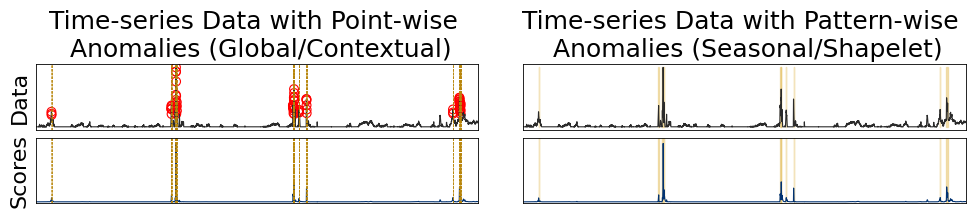

In [8]:
fig = plt.figure(figsize=(12, 1.8*n_algo))

for ii, (y, data, score_df) in enumerate(zip(y_lst, data_lst, score_df_lst)):
    fig.add_subplot(n_algo+1, 2, 1+ii)
    index = score_df.index
    sns.lineplot(x=index, y=data, linewidth=0.8, color=sns.color_palette('Greys_r')[0])
    
    if ii == 0:
        plt.scatter(np.where(y==1)[0], data[np.where(y==1)[0]], color='none', marker='o', linewidth=0.8,
                    alpha=1, edgecolors='r', s=40)
        for idx in np.where(y==1)[0]:
            plt.axvline(idx, color='darkgoldenrod', alpha=1, linewidth=0.5,  linestyle='--')
    else:
        value_min = np.around(data.min(), decimals=1) - 0.1;value_max = np.around(data.max(), decimals=1) + 0.1
        values_ = np.linspace(value_min, value_max, 10)
        for pair in anom_pairs:
            x1 = np.ones(len(values_)) * pair[0];x2 = np.ones(len(values_)) * pair[1]
            plt.fill_betweenx(values_, x1, x2, alpha=0.3, color='goldenrod')

    ax = plt.gca()
    for loc in ['bottom', 'left', 'top', 'right']:
        ax.spines[loc].set_linewidth(0.6)

     
    plt.xlim(left, right)
    plt.xlabel('')
    plt.ylabel('Data' if ii == 0 else '', fontsize=16)
    plt.xticks([])
    plt.yticks([])
    plt.title('Time-series Data with Point-wise \n Anomalies (Global/Contextual)' if ii ==0 else 'Time-series Data with Pattern-wise \n Anomalies (Seasonal/Shapelet)', fontsize=18)

    for jj, algo in enumerate(algo_lst):
        
        ax=fig.add_subplot(n_algo+1, 2, 3+ii+jj*2)
        # palette = sns.color_palette("bone", 6)

        score_df['name'] = algo
        sns.lineplot(x='index', y=algo, data=score_df, hue='name', legend=False, 
                     linewidth=0.8, 
                     # palette=sns.color_palette("ocean", 1)
                     palette=sns.color_palette("cividis", 10)[:1]
                    )
        # plt.legend(loc='upper left', ncol=1, fontsize=16, handlelength=0.3)
        if ii == 0:   
            for idx in np.where(y==1)[0]:
                plt.axvline(idx, color='darkgoldenrod', alpha=1, linewidth=0.5, linestyle='--')
        else:
            values_ = np.linspace(-0.02, 1.1, 10)
            for pair in anom_pairs:
                plt.fill_betweenx(values_, np.ones(len(values_))*pair[0], np.ones(len(values_))*pair[1], alpha=0.3, 
                                  # color='red'
                                  color='goldenrod'
                                 )

        plt.xlim(left, right)
        plt.ylim(-0.02, 1.1)
        plt.xlabel('')
        plt.ylabel('Scores' if ii == 0 else '', fontsize=16)
        plt.xticks([])
        plt.yticks([])
        
        ax = plt.gca()
        for loc in ['bottom', 'left', 'top', 'right']:
            ax.spines[loc].set_linewidth(0.6)

 
plt.subplots_adjust(wspace=0.1, hspace=0.12)
# plt.savefig(f'showcase.pdf', bbox_inches = 'tight')